# SEAM_validate — MSM-mismatch rows for hand-picked clusters

Shows the MSM **% mismatch-to-WT** row (the cluster's slice of the mismatch matrix, `mismatch[pos]` = fraction of members flipped from WT at `pos`) for the clusters picked by hand in `mcs_k562/figure_scripts/wt_summary_panels.ipynb`.

Run there: `REF=peak84030`, `VARIANT=foregrounds_kmeans300`, 100k library → config **`100k_k300`**. Picked clusters (SORTED MSM ids): **8, 118, 134, 186**. These are real multi-position mechanisms (mismatch spread over motif-scale windows), not single-base peaks.

In [1]:
import numpy as np, h5py
from pathlib import Path

R   = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
OUT = Path("/grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results")
OUT.mkdir(parents=True, exist_ok=True)
VAR_START, VAR_END = 15, 215                 # 200bp variable region within the 230bp insert

SELECTED = {"peak26256": "100k_k200", "peak84030": "300k_k300", "peak27535_Reversed": "100k_k300"}

def lib_suffix(fg):
    if fg.startswith("foregrounds_mut5_200k"): return "_mut5_200k"
    if fg.startswith("foregrounds_mut5_300k"): return "_mut5_300k"
    if fg.startswith("foregrounds_mut5"):      return "_mut5"
    if fg.startswith("foregrounds_200k"):      return "_200k"
    if fg.startswith("foregrounds_300k"):      return "_300k"
    return ""
LIB_LABEL = {"": "100k", "_200k": "200k", "_300k": "300k",
             "_mut5": "mut5", "_mut5_200k": "mut5-200k", "_mut5_300k": "mut5-300k"}

def get_run(ref_seq, config_label):
    """Resolve a (ref_seq, 'lib_kK') config to its foreground dir + aligned library/ism h5 paths."""
    for fg in sorted(p.name for p in R.glob("foregrounds*") if p.is_dir()):
        if "deepshap" in fg:
            continue
        fg_dir = R / fg / ref_seq
        suf    = lib_suffix(fg)
        if not (fg_dir / "cluster_labels.npy").exists():
            continue
        labels = np.load(fg_dir / "cluster_labels.npy")
        if f"{LIB_LABEL[suf]}_k{len(np.unique(labels))}" == config_label:
            return dict(fg_dir=fg_dir, suf=suf, labels=labels,
                        lib_h5=R / f"mutagenesis_lib{suf}" / f"{ref_seq}.h5",
                        ism_h5=R / f"ism{suf}" / f"{ref_seq}.h5")
    raise FileNotFoundError(f"no config {config_label!r} for {ref_seq}")

# flip mask depends only on the library -> read+build once per library h5, cache
_flip = {}
def load_flip(path):
    key = str(path)
    if key not in _flip:
        with h5py.File(path) as f:
            seq = f["sequences"][:, VAR_START:VAR_END, :].argmax(2)     # (N,200) base index per position
            wt  = f["wt_sequence"][VAR_START:VAR_END, :].argmax(1)      # (200,) WT base index
        _flip[key] = (seq != wt[None]).astype(np.float64)              # (N,200) 1=flipped from WT
    return _flip[key]

print("configs:", SELECTED)

configs: {'peak26256': '100k_k200', 'peak84030': '300k_k300', 'peak27535_Reversed': '100k_k300'}


In [2]:
def sorted_to_raw(run):
    """Map SEAM SORTED cluster id (the MSM y-axis number) -> RAW k-means label.
    SEAM sort_method='median': clusters ordered by median DNN prediction. sorted_id = index into that order."""
    labels = run["labels"]
    with h5py.File(run["ism_h5"]) as f:
        preds = f["predictions"][:]
    raw_ids = np.unique(labels)
    order   = raw_ids[np.argsort([np.median(preds[labels == k]) for k in raw_ids])]
    return {int(si): int(raw) for si, raw in enumerate(order)}

def msm_mismatch_row(run, sorted_id, s2r):
    """The cluster's row of the MSM mismatch-to-WT matrix: mismatch[pos] = fraction of members flipped at pos."""
    raw = s2r[sorted_id]
    M   = np.where(run["labels"] == raw)[0]
    return load_flip(run["lib_h5"])[M].mean(0), raw, len(M)     # (200,), raw label, size

In [3]:
import matplotlib.pyplot as plt

def msm_mismatch_matrix(run):
    """Full MSM mismatch-to-WT matrix: rows = SORTED cluster ids (SEAM y-axis order),
    cols = position, value = fraction of that cluster's members flipped from WT at that position."""
    s2r  = sorted_to_raw(run)
    flip = load_flip(run["lib_h5"])                          # (N, 200) 1 = flipped from WT
    n    = len(s2r)
    M    = np.zeros((n, VAR_END - VAR_START))
    for sid in range(n):
        members = np.where(run["labels"] == s2r[sid])[0]
        M[sid]  = flip[members].mean(0)
    return M

def plot_msm_heatmap(run, ref_seq, config_label, picked=None, savename=None):
    """Actual MSM % mismatch-to-WT heatmap: sorted clusters (y) x position (x)."""
    M = msm_mismatch_matrix(run)
    fig, ax = plt.subplots(figsize=(13, 8))
    im = ax.imshow(M, aspect="auto", cmap="magma", vmin=0, vmax=float(M.max()),
                   origin="upper", interpolation="nearest",
                   extent=[VAR_START, VAR_END, M.shape[0] - 0.5, -0.5])
    if picked:                                               # mark the hand-picked clusters on the y-axis
        for sid in picked:
            ax.axhline(sid, color="cyan", lw=0.6, alpha=0.8)
        ax.set_yticks(picked); ax.set_yticklabels(picked, fontsize=7, color="darkcyan")
    ax.set_xlabel("position (insert coord)")
    ax.set_ylabel("SORTED cluster id (by median DNN prediction)")
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("% mismatch-to-WT")
    ax.set_title(f"{ref_seq}  {config_label} — MSM % mismatch-to-WT heatmap", fontsize=10)
    fig.tight_layout()
    if savename:
        fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
    plt.show()

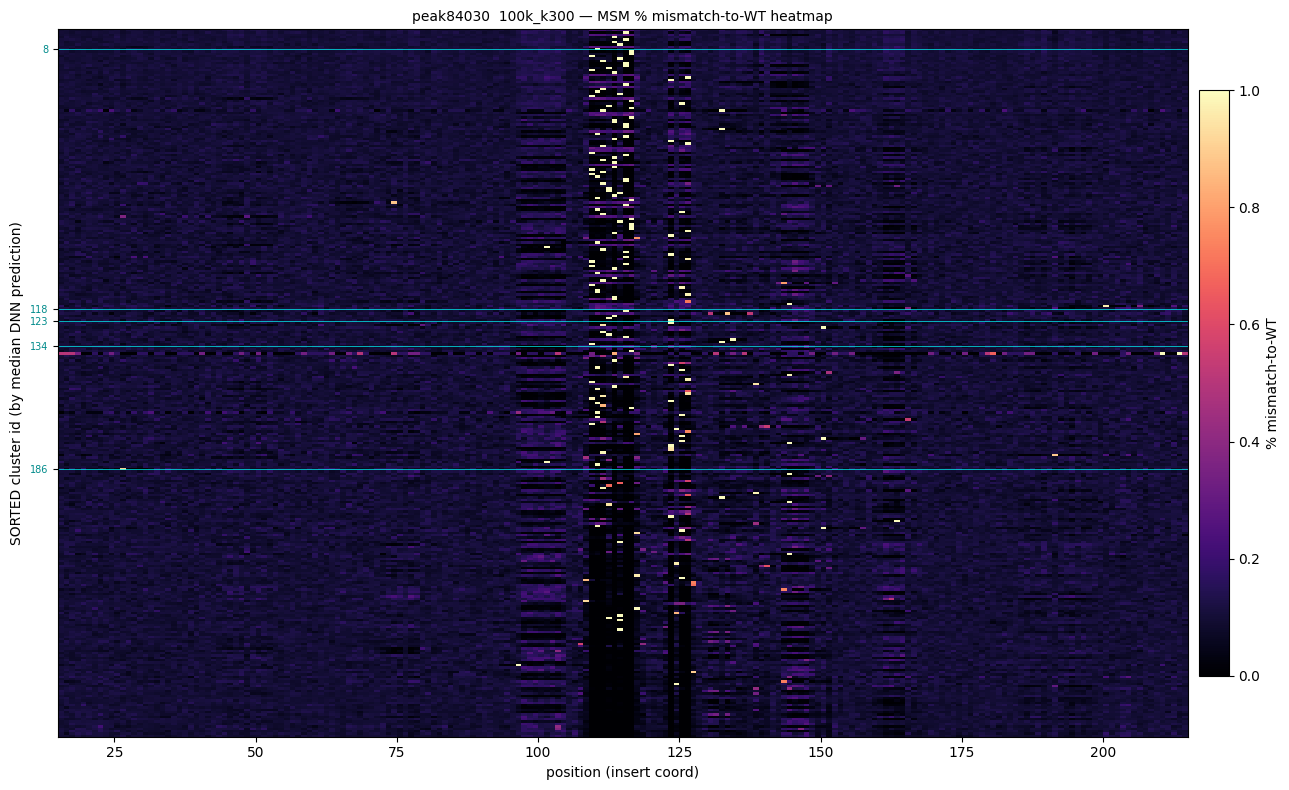

In [4]:
# the clusters picked by hand in mcs_k562/figure_scripts/wt_summary_panels.ipynb
# (REF=peak84030, VARIANT=foregrounds_kmeans300, 100k lib -> config '100k_k300'); ids are SORTED MSM ids.
REF, CONFIG = "peak84030", "100k_k300"
PICKED = [8, 118, 134, 186, 123]

run = get_run(REF, CONFIG)
plot_msm_heatmap(run, REF, CONFIG, picked=PICKED, savename=f"{REF}_{CONFIG}_msm_mismatch_heatmap.png")

In [5]:
# Auto-detect the best clusters: rank ALL clusters of this run by attribution-map COSINE SNR
# (R_cos = mean_i cos(f_i, fbar) / mean_i (1 - cos(f_i, fbar)) over the cluster's ISM maps; high = tight,
# well-aligned mechanism). The WT cluster (contains library row 0) is excluded.
#
# Also EXCLUDE single-position spikes (the "one super-tall letter in the middle" clusters): those are not
# real multi-position mechanisms. Measure the mean map's spread with the participation ratio of per-position
# energy, PR = (sum e)^2 / sum(e^2) (~ effective # of positions); require PR >= MIN_SPREAD.
MIN_SPREAD = 4.0                                            # min effective #positions (drop 1-3 position spikes)

s2r = sorted_to_raw(run)
with h5py.File(run["ism_h5"]) as f:
    ism = f["ism_centered"][:].reshape(f["ism_centered"].shape[0], -1)   # (N, 800)
wt_raw = int(run["labels"][0])

snr_by_sid, spread_by_sid, n_spike = {}, {}, 0
for sid, raw in s2r.items():
    if raw == wt_raw:                                        # skip the WT cluster itself
        continue
    members = np.where(run["labels"] == raw)[0]
    if len(members) < 2:
        continue
    X    = ism[members].astype(np.float64)
    fbar = X.mean(0)
    e    = (fbar.reshape(-1, 4) ** 2).sum(1)                 # (200,) per-position energy of the mean map
    pr   = float(e.sum() ** 2 / ((e ** 2).sum() + 1e-12))    # participation ratio ~ effective # positions
    spread_by_sid[sid] = pr
    if pr < MIN_SPREAD:                                      # single/few-position spike -> exclude
        n_spike += 1
        continue
    cos_ = (X @ fbar) / (np.linalg.norm(X, axis=1) * np.linalg.norm(fbar) + 1e-12)
    snr_by_sid[sid] = float(cos_.mean() / (np.mean(1.0 - cos_) + 1e-12))

TOP = sorted(snr_by_sid, key=snr_by_sid.get, reverse=True)[:10]
print(f"{REF} {CONFIG} — {len(snr_by_sid)} clusters kept, {n_spike} single-position spikes dropped "
      f"(PR < {MIN_SPREAD}). Top 10 by cosine SNR:")
for rank, sid in enumerate(TOP):
    M = int((run["labels"] == s2r[sid]).sum())
    print(f"  rank {rank:2d}  sort {sid:4d}  cosSNR={snr_by_sid[sid]:7.3f}  spread={spread_by_sid[sid]:5.1f}  M={M}")

peak84030 100k_k300 — 266 clusters kept, 33 single-position spikes dropped (PR < 4.0). Top 10 by cosine SNR:
  rank  0  sort  297  cosSNR= 33.318  spread= 11.0  M=422
  rank  1  sort  299  cosSNR= 33.060  spread=  9.9  M=588
  rank  2  sort  294  cosSNR= 31.094  spread= 10.7  M=591
  rank  3  sort  275  cosSNR= 30.265  spread= 12.1  M=639
  rank  4  sort  295  cosSNR= 29.950  spread= 12.8  M=217
  rank  5  sort  296  cosSNR= 29.266  spread= 11.6  M=362
  rank  6  sort  291  cosSNR= 29.119  spread= 12.2  M=339
  rank  7  sort  282  cosSNR= 29.073  spread= 11.2  M=770
  rank  8  sort  289  cosSNR= 28.438  spread= 10.8  M=605
  rank  9  sort  293  cosSNR= 27.383  spread= 10.2  M=829


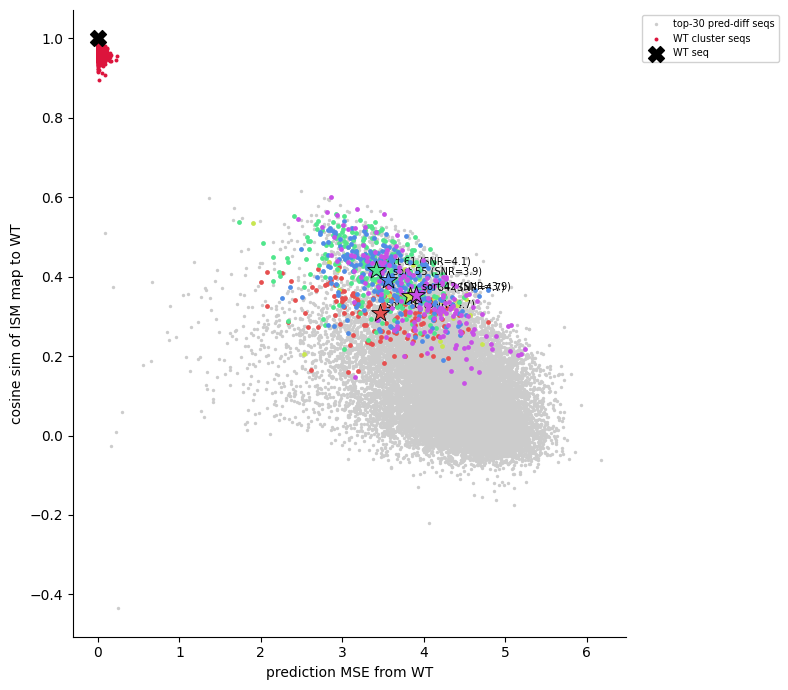

EXTREME (top-30 by pred diff): [0, 7, 19, 22, 23, 24, 29, 31, 36, 35, 37, 39, 42, 43, 34, 44, 47, 48, 45, 46, 50, 49, 51, 55, 53, 58, 59, 61, 57, 60]
FINAL (5 best SNR among extremes): [(58, 4.7), (34, 4.65), (61, 4.13), (55, 3.94), (42, 3.93)]
saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_top30_seq_mse_vs_cos.png


In [6]:
# Per-SEQUENCE 2D space: x = pred MSE from WT, y = cosine sim of ISM map to WT. Each dot is a sequence;
# WT-cluster members colored separately. SELECTION: first take the extremes by prediction difference from
# WT (top-N clusters by centroid pred MSE), THEN cut down to the best 5 of those by attribution SNR.
import colorsys

with h5py.File(run["ism_h5"]) as f:
    preds = f["predictions"][:]
pred_flat = preds.reshape(len(preds), -1).astype(np.float64)
mse = np.mean((pred_flat - pred_flat[0]) ** 2, axis=1)                    # (N,) pred MSE from WT (row 0)
wt_map = ism[0]
cos = (ism @ wt_map) / (np.linalg.norm(ism, axis=1) * np.linalg.norm(wt_map) + 1e-12)   # (N,) cos to WT map

N_EXTREME, N_FINAL = 30, 5
cand            = list(snr_by_sid)                                        # all non-WT clusters
wt_members      = np.where(run["labels"] == wt_raw)[0]
mem             = {sid: np.where(run["labels"] == s2r[sid])[0] for sid in cand}
pred_mse_by_sid = {sid: float(mse[mem[sid]].mean()) for sid in cand}      # centroid pred MSE from WT

EXTREME = sorted(cand, key=pred_mse_by_sid.get, reverse=True)[:N_EXTREME] # 1) biggest prediction difference
FINAL   = sorted(EXTREME, key=snr_by_sid.get, reverse=True)[:N_FINAL]     # 2) cleanest of those by SNR
cent    = {sid: (pred_mse_by_sid[sid], float(cos[mem[sid]].mean())) for sid in EXTREME}

fig, ax = plt.subplots(figsize=(8, 7))
allmem = np.concatenate([mem[sid] for sid in EXTREME])
ax.scatter(mse[allmem], cos[allmem], s=6, color="0.8", lw=0, zorder=1, label=f"top-{N_EXTREME} pred-diff seqs")
ax.scatter(mse[wt_members], cos[wt_members], s=8, color="crimson", lw=0, zorder=2, label="WT cluster seqs")

colors = [colorsys.hsv_to_rgb(i / N_FINAL, 0.65, 0.90) for i in range(N_FINAL)]   # unique color per final cluster
for col, sid in zip(colors, FINAL):
    ax.scatter(mse[mem[sid]], cos[mem[sid]], s=12, color=col, lw=0, zorder=3)
    cx, cy = cent[sid]
    ax.scatter([cx], [cy], s=180, marker="*", color=col, edgecolor="black", linewidth=0.6, zorder=4)
    ax.annotate(f"sort {sid} (SNR={snr_by_sid[sid]:.1f})", (cx, cy), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.scatter([0], [1], s=130, marker="X", color="black", zorder=5, label="WT seq")

ax.set_xlabel("prediction MSE from WT"); ax.set_ylabel("cosine sim of ISM map to WT")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)
fig.tight_layout()
savename = f"{REF}_{CONFIG}_top30_seq_mse_vs_cos.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print(f"EXTREME (top-{N_EXTREME} by pred diff):", EXTREME)
print(f"FINAL ({N_FINAL} best SNR among extremes):", [(sid, round(snr_by_sid[sid], 2)) for sid in FINAL])
print("saved:", OUT / savename)

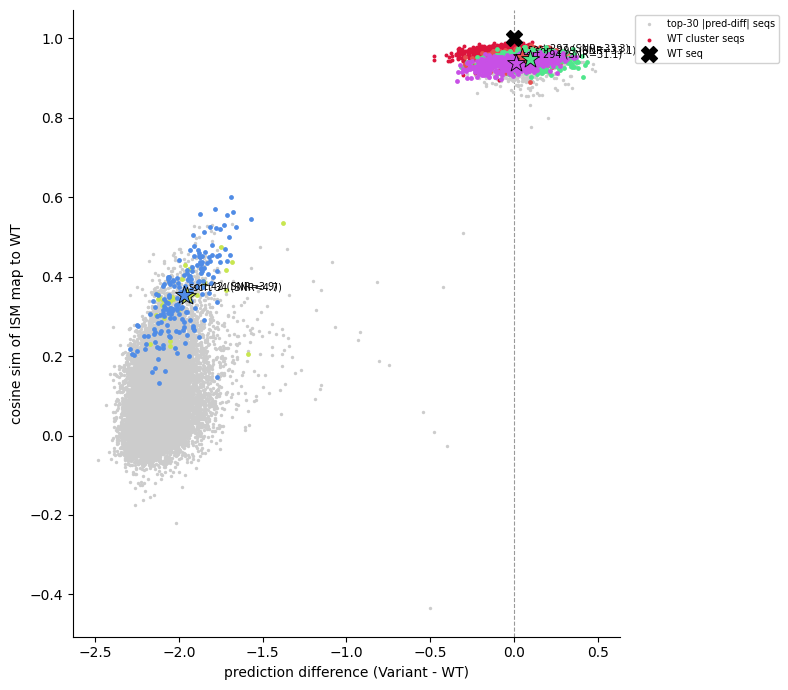

EXTREME_s (6 above + 15 below WT): [299, 298, 297, 296, 295, 294, 0, 7, 22, 19, 23, 24, 29, 31, 36, 35, 37, 39, 42, 43, 34]
FINAL_s (5, both directions by SNR): [(297, 0.049, 33.32), (34, -1.949, 4.65), (299, 0.094, 33.06), (42, -1.973, 3.93), (294, 0.009, 31.09)]
saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_top30_seq_signeddiff_vs_cos.png


In [7]:
# Signed-prediction version: x = Variant - WT (goes both directions), y = cosine sim of ISM map to WT.
# Extremes are taken from BOTH tails (most above WT AND most below WT), then cut to 5 by cosine SNR while
# keeping both directions represented (interleave best-SNR above / below).
pred_scalar = pred_flat.mean(axis=1)                                     # scalar prediction per seq
delta = pred_scalar - pred_scalar[0]                                     # (N,) Variant - WT (signed)

deltac = {sid: float(delta[mem[sid]].mean()) for sid in cand}           # centroid signed pred diff
half   = N_EXTREME // 2
above  = sorted([s for s in cand if deltac[s] > 0], key=deltac.get, reverse=True)[:half]   # most above WT
below  = sorted([s for s in cand if deltac[s] < 0], key=deltac.get)[:half]                 # most below WT
EXTREME_s = above + below

ba, bb = sorted(above, key=snr_by_sid.get, reverse=True), sorted(below, key=snr_by_sid.get, reverse=True)
FINAL_s = []
for a, b in zip(ba, bb):                                                 # interleave -> both directions kept
    FINAL_s += [a, b]
FINAL_s = (FINAL_s + ba[len(bb):] + bb[len(ba):])[:N_FINAL]
cent_s  = {sid: (deltac[sid], float(cos[mem[sid]].mean())) for sid in EXTREME_s}

fig, ax = plt.subplots(figsize=(8, 7))
allmem = np.concatenate([mem[sid] for sid in EXTREME_s])
ax.scatter(delta[allmem], cos[allmem], s=6, color="0.8", lw=0, zorder=1, label=f"top-{N_EXTREME} |pred-diff| seqs")
ax.scatter(delta[wt_members], cos[wt_members], s=8, color="crimson", lw=0, zorder=2, label="WT cluster seqs")

colors = [colorsys.hsv_to_rgb(i / N_FINAL, 0.65, 0.90) for i in range(N_FINAL)]
for col, sid in zip(colors, FINAL_s):
    ax.scatter(delta[mem[sid]], cos[mem[sid]], s=12, color=col, lw=0, zorder=3)
    cx, cy = cent_s[sid]
    ax.scatter([cx], [cy], s=180, marker="*", color=col, edgecolor="black", linewidth=0.6, zorder=4)
    ax.annotate(f"sort {sid} (SNR={snr_by_sid[sid]:.1f})", (cx, cy), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.scatter([0], [1], s=130, marker="X", color="black", zorder=5, label="WT seq")
ax.axvline(0, color="0.6", lw=0.8, ls="--", zorder=0)                    # WT prediction reference

ax.set_xlabel("prediction difference (Variant - WT)"); ax.set_ylabel("cosine sim of ISM map to WT")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)
fig.tight_layout()
savename = f"{REF}_{CONFIG}_top30_seq_signeddiff_vs_cos.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print(f"EXTREME_s ({len(above)} above + {len(below)} below WT):", EXTREME_s)
print(f"FINAL_s ({N_FINAL}, both directions by SNR):",
      [(sid, round(deltac[sid], 3), round(snr_by_sid[sid], 2)) for sid in FINAL_s])
print("saved:", OUT / savename)

FOCUS = sort 34  (rank 1, SNR=4.652)


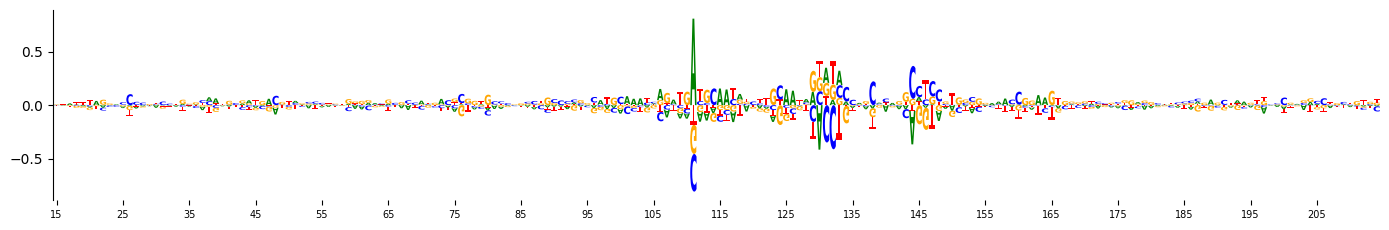

In [8]:
import sys
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

RANK_IDX = 1                    # 0..4 -> index through the 5 selected clusters (FINAL_s: signed pred-diff extremes, best SNR)
FOCUS    = FINAL_s[RANK_IDX]     # SORTED cluster id currently in focus
print(f"FOCUS = sort {FOCUS}  (rank {RANK_IDX}, SNR={snr_by_sid[FOCUS]:.3f})")

def plot_cluster_logo(run, sorted_id, ref_seq, config_label, savename=None):
    """Mean attribution-map logo for one SORTED cluster id (cluster_maps.npy is SORTED-indexed)."""
    cmap = np.load(run["fg_dir"] / "cluster_maps.npy")[sorted_id]        # (200,4) mean attribution map
    fig, ax = plt.subplots(figsize=(14, 2.4))
    fast_logo(cmap, ax); ax.set_xlim(-0.5, 199.5)
    ax.set_xticks(np.arange(0, 200, 10)); ax.set_xticklabels(np.arange(0, 200, 10) + VAR_START, fontsize=7)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
    fig.tight_layout()
    if savename:
        fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
    plt.show()

plot_cluster_logo(run, FOCUS, REF, CONFIG, savename=f"{REF}_{CONFIG}_sort{FOCUS}_logo.png")

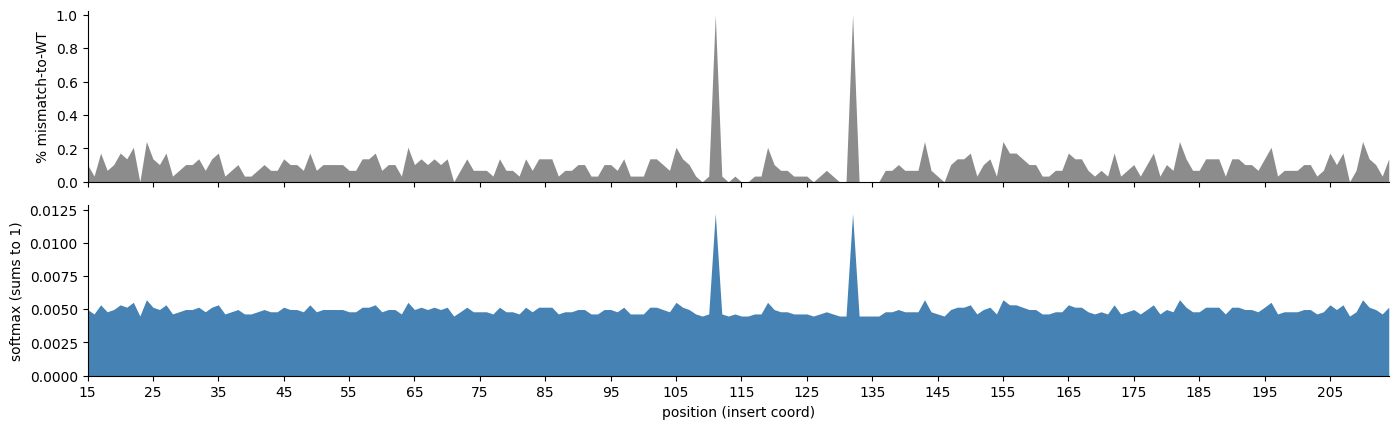

saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_sort34_mismatch_profile.png   softmax sum = 0.9999999999999999


In [9]:
# MSM % mismatch-to-WT profile for the focus cluster alone -> how sharply the causal signal is defined.
# Top: raw per-position mismatch fraction. Bottom: softmax over positions (a distribution summing to 1).
s2r        = sorted_to_raw(run)
mm, raw, M = msm_mismatch_row(run, FOCUS, s2r)                 # (200,) frac of members flipped from WT per pos
x          = np.arange(VAR_START, VAR_END)
sm         = np.exp(mm - mm.max()); sm /= sm.sum()            # softmax over positions -> sums to 1

fig, axes = plt.subplots(2, 1, figsize=(14, 4.4), sharex=True)
axes[0].fill_between(x, 0, mm, color="0.55", lw=0)
axes[0].set_ylim(0, 1.02); axes[0].set_ylabel("% mismatch-to-WT")
axes[1].fill_between(x, 0, sm, color="steelblue", lw=0)
axes[1].set_ylim(0, sm.max() * 1.05); axes[1].set_ylabel("softmax (sums to 1)")
axes[1].set_xlabel("position (insert coord)")
for ax in axes:
    ax.set_xlim(VAR_START, VAR_END - 1); ax.set_xticks(np.arange(VAR_START, VAR_END, 10))
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.tight_layout()
savename = f"{REF}_{CONFIG}_sort{FOCUS}_mismatch_profile.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename, "  softmax sum =", float(sm.sum()))

peak84030 100k_k300   causality = ||mismatch_c||^2   (nrep=800 random null draws)
sortID  raw      M    real null_mean null_std       z
   297  180    422   1.712     2.041    0.046    -7.2
    34  299     29   4.270     2.620    0.198     8.3
   299  174    588   1.944     2.032    0.038    -2.3
    42  192    178   3.041     2.103    0.066    14.1
   294   18    591   2.157     2.030    0.037     3.4


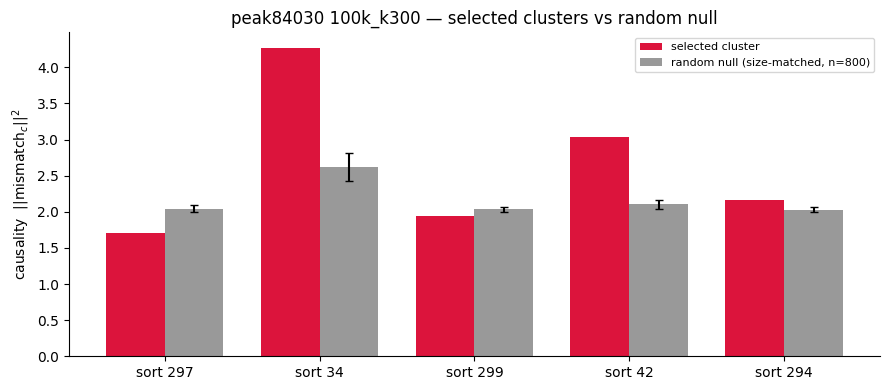

In [10]:
# causality score of each SELECTED cluster (FINAL_s) vs a size-matched random null.
# causality = ||mismatch_c||^2 = sum_pos mismatch_c[pos]^2.  null = same score for random subsets of the
# SAME size drawn from the library (its members share no mechanism), giving mean +/- std over nrep draws.
CLUSTERS = FINAL_s                                           # the auto-selected clusters from the scatter cell
s2r   = sorted_to_raw(run)
flip  = load_flip(run["lib_h5"])
N     = len(flip)
nrep  = 800
rng   = np.random.default_rng(0)

print(f"{REF} {CONFIG}   causality = ||mismatch_c||^2   (nrep={nrep} random null draws)")
print(f"{'sortID':>6} {'raw':>4} {'M':>6} {'real':>7} {'null_mean':>9} {'null_std':>8} {'z':>7}")
real_v, null_m, null_s = [], [], []
for sid in CLUSTERS:
    mm, raw, M = msm_mismatch_row(run, sid, s2r)
    real = float((mm ** 2).sum())
    null = np.array([((flip[rng.integers(0, N, M)].mean(0)) ** 2).sum() for _ in range(nrep)])
    z = (real - null.mean()) / (null.std() + 1e-12)
    real_v.append(real); null_m.append(null.mean()); null_s.append(null.std())
    print(f"{sid:6d} {raw:4d} {M:6d} {real:7.3f} {null.mean():9.3f} {null.std():8.3f} {z:7.1f}")

x = np.arange(len(CLUSTERS)); W = 0.38
fig, ax = plt.subplots(figsize=(1.4 * len(CLUSTERS) + 2, 4))
ax.bar(x - W/2, real_v, W, color="crimson", label="selected cluster")
ax.bar(x + W/2, null_m, W, yerr=null_s, capsize=3, color="0.6", label=f"random null (size-matched, n={nrep})")
ax.set_xticks(x); ax.set_xticklabels([f"sort {s}" for s in CLUSTERS])
ax.set_ylabel("causality  ||mismatch$_c$||$^2$")
ax.set_title(f"{REF} {CONFIG} — selected clusters vs random null")
ax.spines[["top", "right"]].set_visible(False); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / f"{REF}_{CONFIG}_selected_causality_vs_null.png", dpi=150, bbox_inches="tight")
plt.show()

sort 34 (raw 299, M=29): causal positions [np.int64(96), np.int64(117)]  (insert [np.int64(111), np.int64(132)]);  per-seq coverage: mean 1.000, min 1.000
sort 42 (raw 192, M=178): causal positions [np.int64(117)]  (insert [np.int64(132)]);  per-seq coverage: mean 1.000, min 1.000


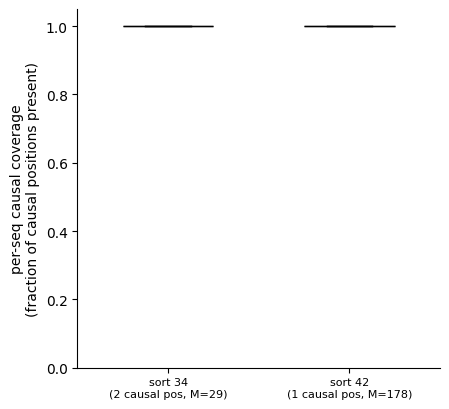

saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_sort34_42_causal_coverage_box.png


In [11]:
# For clusters 34 & 42 (SORTED): define the CAUSAL mask = positions near 100% cluster mismatch (mm >= THR),
# i.e. the flips essentially every member shares. To show the seqs really do carry these (NOT the misleading
# per-mutation pooling, which is drowned by each seq's ~18 random neutral muts), box per-seq CAUSAL COVERAGE
# = fraction of the cluster's causal positions that each sequence actually has flipped.
FOCUS_CLUSTERS = [34, 42]
THR_CAUSAL     = 0.9
s2r  = sorted_to_raw(run)
flip = load_flip(run["lib_h5"])                            # (N, 200) binary flip-from-WT mask per seq

data, box_labels = [], []
for sid in FOCUS_CLUSTERS:
    mm, raw, M = msm_mismatch_row(run, sid, s2r)           # (200,) fraction of members flipped per pos
    members    = np.where(run["labels"] == raw)[0]
    causal_pos = np.where(mm >= THR_CAUSAL)[0]             # the near-100% positions
    cov        = flip[members][:, causal_pos].mean(1)      # per-seq: fraction of causal positions present
    data.append(cov)
    box_labels.append(f"sort {sid}\n({len(causal_pos)} causal pos, M={M})")
    print(f"sort {sid} (raw {raw}, M={M}): causal positions {list(causal_pos)}  "
          f"(insert {list(causal_pos + VAR_START)});  per-seq coverage: mean {cov.mean():.3f}, min {cov.min():.3f}")

fig, ax = plt.subplots(figsize=(1.8 * len(data) + 1, 4.2))
bp = ax.boxplot(data, showfliers=True, patch_artist=True, widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor("crimson"); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("black")
ax.set_xticklabels(box_labels, fontsize=8)
ax.set_ylabel("per-seq causal coverage\n(fraction of causal positions present)")
ax.set_ylim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
savename = f"{REF}_{CONFIG}_sort34_42_causal_coverage_box.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename)

AlphaGenome patches applied (all functional activations -> nn.Module).
loaded K562 model
sort 34: 2 causal flips (insert pos [np.int64(111), np.int64(132)]) -> pred delta=-1.822, cos=0.454
sort 42: 1 causal flips (insert pos [np.int64(132)]) -> pred delta=-0.623, cos=0.889


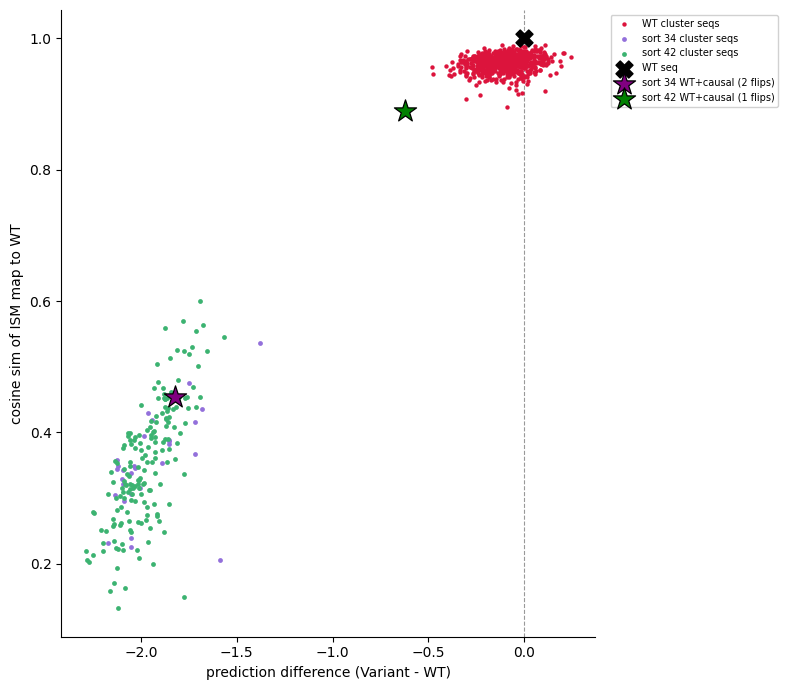

saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_causal_only_constructs_on_scatter.png


In [12]:
# EXPERIMENT: take WT and flip ONLY the causal positions (mm >= THR_CAUSAL) of clusters 34 & 42 -> 2 new seqs
# (one per cluster). Score each with the K562 MPRA model exactly as the library was scored (SEAM_ism.py).
# Construct layout (insert = 230bp): 15bp adapter + 200bp VARIABLE REGION [15:215] + 15bp adapter; then the
# model's construct suffix (36bp promoter + 15bp barcode) is appended -> 281bp model input. Only the 200bp
# variable region is ever mutated. ISM = mutate-all-4 over the variable region, then mean-center per position.
# Plot only the TARGET seqs: WT cluster + the 34 & 42 cluster seqs + the 2 new WT+causal constructs.
#   NB: needs a GPU + the model env (the .venv-ageft-pytorch / hippo build used to build the library).
import torch, torch.nn as nn
EI_DIR = "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/eigen-interactions"
if EI_DIR not in sys.path:
    sys.path.insert(0, EI_DIR)
from ag_deeplift_patches import patch_alphagenome
from alphagenome_encoder_ft import EncoderMPRAModel
patch_alphagenome()
CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
VS, VE, EL = 15, 215, 230; LVAR = VE - VS; NMUT = LVAR * 4          # VS/VE = variable region within the 230bp insert
THR_CAUSAL = 0.9
TARGETS = [34, 42]

def _oh_cf(s):
    m = {'A': 0, 'C': 1, 'G': 2, 'T': 3}; o = np.zeros((4, len(s)), np.float32)
    for j, b in enumerate(s):
        if b in m: o[m[b], j] = 1.0
    return o

if "K562_MODEL" not in globals():
    ck = torch.load(CKPT, map_location="cpu", weights_only=False); cc = ck["construct_config"]
    K562_SUFFIX = _oh_cf(cc["promoter_seq"] + cc["barcode_seq"])              # (4, 51) = 36bp promoter + 15bp barcode
    class _TW(nn.Module):
        def __init__(s, m): super().__init__(); s.m = m
        def forward(s, x):
            o = s.m(x.transpose(-1, -2)); return o.unsqueeze(-1) if o.dim() == 1 else o
    K562_MODEL = _TW(EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()).cuda().eval()
    print("loaded K562 model")

def _make_ism_inputs(x_cf):                                                  # (4,230) -> (801,4,230); mutate only [VS:VE]
    out = np.broadcast_to(x_cf, (NMUT + 1, 4, EL)).copy()
    pos = np.repeat(np.arange(LVAR), 4); base = np.tile(np.arange(4), LVAR); cols = (VS + pos).astype(np.int64)
    mr = 1 + np.arange(NMUT)
    out[mr[:, None], np.arange(4)[None, :], cols[:, None]] = 0.0
    out[mr, base, cols] = 1.0
    return out

@torch.no_grad()
def score_insert(x_oh):                                                      # (230,4) -> pred, ism_centered(200,4)
    x_all = np.concatenate([_make_ism_inputs(x_oh.transpose(1, 0).astype(np.float32)),
                            np.broadcast_to(K562_SUFFIX, (NMUT + 1, 4, K562_SUFFIX.shape[1]))], axis=2)  # (801,4,281)
    preds = np.empty(len(x_all), np.float32)
    for i in range(0, len(x_all), 1024):
        preds[i:i+1024] = K562_MODEL(torch.from_numpy(x_all[i:i+1024]).float().cuda()).squeeze(-1).cpu().numpy()
    ism = (preds[1:] - preds[0]).reshape(LVAR, 4)
    return float(preds[0]), (ism - ism.mean(-1, keepdims=True))              # (200,4) mean-centered

with h5py.File(run["lib_h5"]) as f:
    seqs = f["sequences"][:]                                                 # (N, 230, 4) full insert (adapters + var)
wt_insert = seqs[0]; wt_map = ism[0]; wt_pred = float(pred_flat[0].mean())

target_members, constructs = {}, {}
for sid in TARGETS:
    mm, raw, M = msm_mismatch_row(run, sid, s2r)
    members  = np.where(run["labels"] == raw)[0]
    target_members[sid] = members
    causal_p = np.where(mm >= THR_CAUSAL)[0]                                 # causal positions WITHIN the 200bp var region
    x = wt_insert.copy()
    for p in causal_p:                                                       # flip WT -> cluster consensus mutant base
        col = VS + p; b = np.bincount(seqs[members, col, :].argmax(1), minlength=4).argmax()
        x[col] = 0; x[col, b] = 1
    pred, ismc = score_insert(x)                                            # ismc (200,4)
    constructs[sid] = dict(delta=pred - wt_pred, ncausal=len(causal_p), ism=ismc,
                           cos=float(ismc.ravel() @ wt_map / (np.linalg.norm(ismc) * np.linalg.norm(wt_map) + 1e-12)))
    print(f"sort {sid}: {len(causal_p)} causal flips (insert pos {list(causal_p + VS)}) -> "
          f"pred delta={constructs[sid]['delta']:+.3f}, cos={constructs[sid]['cos']:.3f}")

clus_colors = {34: "mediumpurple", 42: "mediumseagreen"}     # cluster seqs (light)
star_colors = {34: "purple",       42: "green"}              # WT+causal construct (dark)
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(delta[wt_members], cos[wt_members], s=10, color="crimson", lw=0, zorder=2, label="WT cluster seqs")
for sid in TARGETS:
    m = target_members[sid]
    ax.scatter(delta[m], cos[m], s=12, color=clus_colors[sid], lw=0, zorder=3, label=f"sort {sid} cluster seqs")
ax.axvline(0, color="0.6", lw=0.8, ls="--", zorder=0)
ax.scatter([0], [1], s=150, marker="X", color="black", zorder=5, label="WT seq")
for sid in TARGETS:
    c = constructs[sid]
    ax.scatter([c["delta"]], [c["cos"]], s=280, marker="*", color=star_colors[sid], edgecolor="black",
               linewidth=0.9, zorder=6, label=f"sort {sid} WT+causal ({c['ncausal']} flips)")
ax.set_xlabel("prediction difference (Variant - WT)"); ax.set_ylabel("cosine sim of ISM map to WT")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)
fig.tight_layout()
savename = f"{REF}_{CONFIG}_causal_only_constructs_on_scatter.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename)

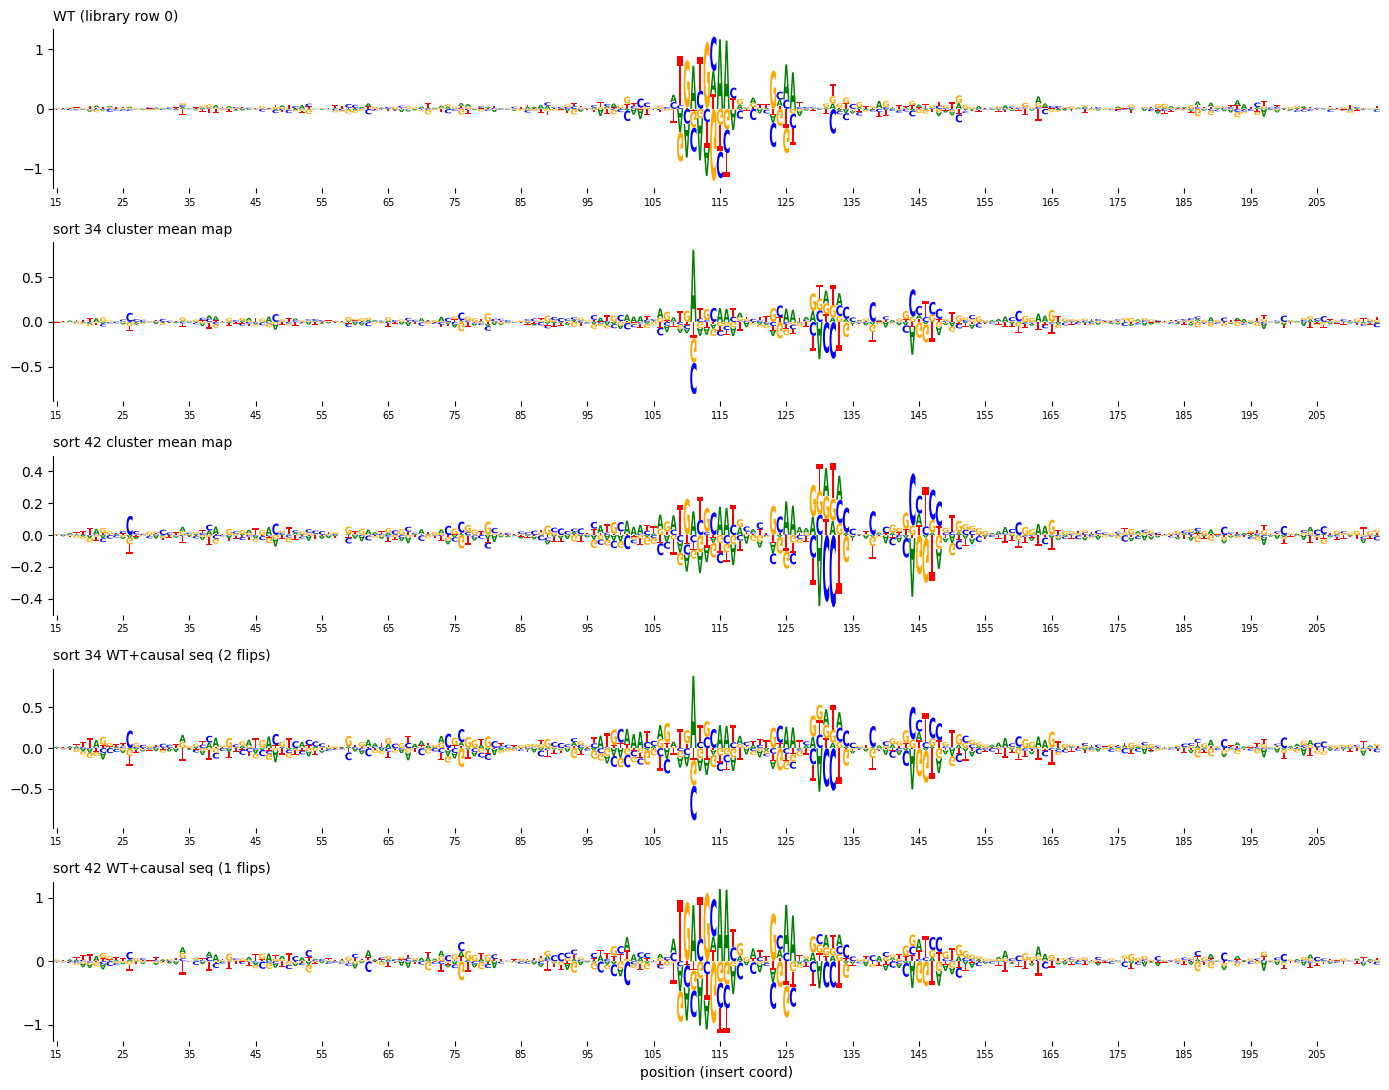

saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_wt_clusters_causal_ism_logos.png


In [13]:
# ISM logos: WT map, the two cluster MEAN attribution maps (sort 34 & 42), and the two new WT+causal seqs.
cmaps = np.load(run["fg_dir"] / "cluster_maps.npy")                          # (n_clusters, 200, 4) SORTED-indexed means
panels = [("WT (library row 0)", ism[0].reshape(LVAR, 4))]
for sid in TARGETS:
    panels.append((f"sort {sid} cluster mean map", cmaps[sid]))
for sid in TARGETS:
    panels.append((f"sort {sid} WT+causal seq ({constructs[sid]['ncausal']} flips)", constructs[sid]["ism"]))

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2.2 * len(panels)), sharex=False, squeeze=False)
for ax, (title, m) in zip(axes[:, 0], panels):
    fast_logo(m, ax); ax.set_xlim(-0.5, 199.5)
    ax.set_xticks(np.arange(0, 200, 10)); ax.set_xticklabels(np.arange(0, 200, 10) + VS, fontsize=7)
    ax.set_title(title, loc="left", fontsize=10)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (insert coord)")
fig.tight_layout()
savename = f"{REF}_{CONFIG}_wt_clusters_causal_ism_logos.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename)

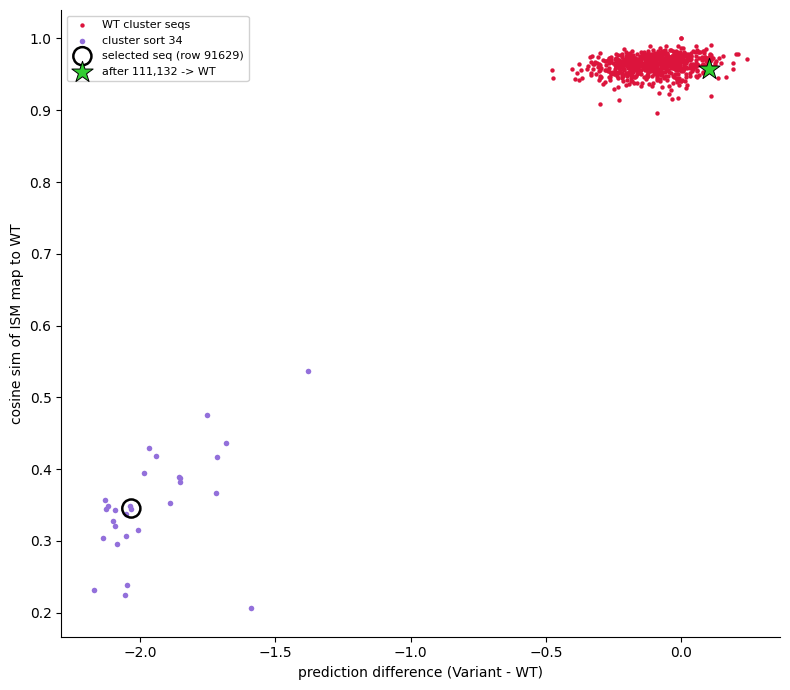

picked lib row 91629 (cluster sort 34, raw 299); reverted insert pos [111, 132] to WT
  before : delta=-2.032  cos=0.345
  after  : delta=+0.103  cos=0.957
saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_sort34_flip111_132_rescue_scatter.png


In [23]:
# RESCUE (scatter): random member of cluster SORT 34 with its two key causal positions (insert 111 & 132
# = var idx 96 & 117, the mm~1.0 shared flips) reverted to WT, all its other mutations kept. Model-scored
# with score_insert (cell 12). Same pred-diff vs cosine-sim space: WT-cluster members + cluster-34 members,
# the picked seq circled, a star where it lands after the revert. (Maps in the next cell.)
# Needs cell 7 (delta/cos/wt_members) and cell 12 (score_insert/seqs/wt_insert/wt_pred/wt_map/ism) run first.
FLIP_INSERT = [111, 132]
SORT34 = 34
raw34  = s2r[SORT34]
mem34  = np.where(run["labels"] == raw34)[0]

rng   = np.random.default_rng(3)
pick  = int(rng.choice(mem34))                             # a random cluster-34 sequence
x_rev = seqs[pick].copy()                                  # (230,4) its full insert
for c in FLIP_INSERT:                                      # revert the two causal positions to WT
    x_rev[c] = wt_insert[c]

pred_rev, ism_rev = score_insert(x_rev)                    # (pred, ism_centered (200,4)) model-scored
delta_rev = pred_rev - wt_pred
cos_rev   = float(ism_rev.ravel() @ wt_map /
                  (np.linalg.norm(ism_rev) * np.linalg.norm(wt_map) + 1e-12))
member_map = ism[pick].reshape(LVAR, 4)                    # selected member attribution map (for next cell)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(delta[wt_members], cos[wt_members], s=10, color="crimson", lw=0, zorder=1, label="WT cluster seqs")
ax.scatter(delta[mem34], cos[mem34], s=16, color="mediumpurple", lw=0, zorder=2, label="cluster sort 34")
ax.scatter(delta[pick], cos[pick], s=170, marker="o", facecolor="none",
           edgecolor="black", linewidth=1.8, zorder=3, label=f"selected seq (row {pick})")
ax.scatter([delta_rev], [cos_rev], s=260, marker="*", color="limegreen",
           edgecolor="black", linewidth=0.7, zorder=4, label="after 111,132 -> WT")
ax.set_xlabel("prediction difference (Variant - WT)")
ax.set_ylabel("cosine sim of ISM map to WT")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, loc="best", framealpha=0.9)
fig.tight_layout()
savename = f"{REF}_{CONFIG}_sort34_flip111_132_rescue_scatter.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print(f"picked lib row {pick} (cluster sort {SORT34}, raw {raw34}); reverted insert pos {FLIP_INSERT} to WT")
print(f"  before : delta={delta[pick]:+.3f}  cos={cos[pick]:.3f}")
print(f"  after  : delta={delta_rev:+.3f}  cos={cos_rev:.3f}")
print("saved:", OUT / savename)


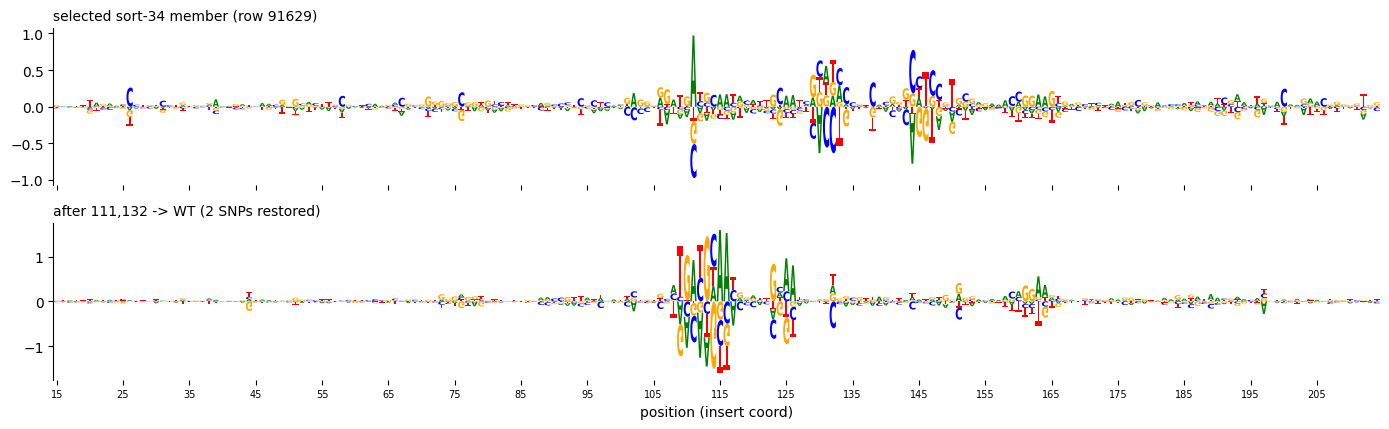

saved: /grid/koo/home/pmantill/projects/SEAM_validate/causal_assess/results/peak84030_100k_k300_sort34_flip111_132_rescue_maps.png


In [24]:
# RESCUE (maps): attribution map for the selected sort-34 member, and after its two causal SNPs
# (insert 111 & 132) are restored to WT. Uses member_map / ism_rev / pick from the scatter cell above.
fig, axes = plt.subplots(2, 1, figsize=(14, 4.4), sharex=True)
for axl, (title, m) in zip(axes,
                           [(f"selected sort-34 member (row {pick})", member_map),
                            (f"after 111,132 -> WT ({len(FLIP_INSERT)} SNPs restored)", ism_rev)]):
    fast_logo(m, axl); axl.set_xlim(-0.5, 199.5)
    axl.set_xticks(np.arange(0, 200, 10)); axl.set_xticklabels(np.arange(0, 200, 10) + VS, fontsize=7)
    axl.set_title(title, loc="left", fontsize=10)
    for sp in ("top", "right", "bottom"): axl.spines[sp].set_visible(False)
axes[-1].set_xlabel("position (insert coord)")
fig.tight_layout()
savename = f"{REF}_{CONFIG}_sort34_flip111_132_rescue_maps.png"
fig.savefig(OUT / savename, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename)
